# 📉 EduNilai — Cost-Squeeze Analysis

**Stage:** 03 — Core Analysis
**Narrative:** *Malaysia's graduates are paying more, earning relatively less, and landing in lower-skill jobs at increasing rates. The degree premium is being squeezed from both ends.*

---

## 🗺️ Analysis Structure

| Section | Question |
|---|---|
| A | How has the **real cost** of a degree changed since 2010? |
| B | How many **months of household income** does a degree cost? (Affordability Index) |
| C | How has graduate **underemployment** trended — and what does COVID reveal? |
| D | Combining all three: the **Cost-Squeeze Score** per field |
| E | Key findings table for the final report |


## ⚙️ Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#6B7280'
PURPLE = '#7C3AED'

# ── Load data — use cleaned folder if available, else raw ─────────────
import os
BASE = '../data/cleaned' if os.path.exists('../data/cleaned') else '../data'

def load(subpath_cleaned, subpath_raw=None):
    clean = f'../data/cleaned/{subpath_cleaned}'
    raw   = f'../data/{subpath_raw or subpath_cleaned}'
    path  = clean if os.path.exists(clean) else raw
    return pd.read_csv(path)

fees_mean = load('fees_mean.csv',    'cost/edunilai_mean_fees.csv')
fees_raw  = load('fees_raw.csv',     'cost/edunilai_raw_fees.csv')
cpi       = load('cpi.csv',          'inflation/cpi_2010_onwards.csv')
hh_nat    = load('hh_income_national.csv', 'demographic/hh_income_national.csv')
sru_sex   = load('graduate_underemployment_sex.csv',  'salary/graduate_underemployment_sex.csv')
sru_age   = load('graduate_underemployment_age.csv',  'salary/graduate_underemployment_age.csv')
lfs       = load('lfs_annual_sex.csv', 'salary/lfs_annual_sex.csv')
youth     = load('youth_unemployment_monthly.csv', 'salary/youth_unemployment_monthly.csv')

# Standardise lfs sex column
lfs['sex'] = lfs['sex'].replace({'both': 'overall'})

# Rename sru_person if present
if 'sru_person' in sru_sex.columns:
    sru_sex = sru_sex.rename(columns={'sru_person': 'sru_persons'})

# Compute public/private avg for fees
fees_mean['public_avg']  = fees_mean[['UTM', 'UM']].mean(axis=1)
fees_mean['private_avg'] = fees_mean[["APU", "Taylor's"]].mean(axis=1)

# CPI reference series
cpi_overall = cpi[cpi['division'] == 'overall'].copy()
cpi_edu     = cpi[cpi['division'] == '10'].copy()   # Education CPI

# # Base year index values (2010)
cpi_overall['date'] = pd.to_datetime(cpi_overall['date'])
cpi_edu['date']     = pd.to_datetime(cpi_edu['date'])
CPI_BASE_OVERALL = cpi_overall[cpi_overall['date'].dt.year == 2010]['index'].values[0]
CPI_BASE_EDU     = cpi_edu[cpi_edu['date'].dt.year == 2010]['index'].values[0]

print("Data loaded.")
print(f"  CPI base (overall, 2010): {CPI_BASE_OVERALL:.2f}")
print(f"  CPI base (education, 2010): {CPI_BASE_EDU:.2f}")


Data loaded.
  CPI base (overall, 2010): 100.02
  CPI base (education, 2010): 100.00


---
## 📈 A. Real Cost of a Degree (CPI-Adjusted)

Tuition fees collected are **current nominal values** (fees charged today).
To compare against household income from 2012-2022, we deflate everything to **2010 RM** using the Education CPI (COICOP division 10).

**Formula:**
> Real fee (2010 RM) = Nominal fee × (CPI_education_2010 / CPI_education_current)


In [4]:
# ── A1: Deflation factor — how much has education inflation eroded RM? ─
cpi_edu_2010   = CPI_BASE_EDU
cpi_edu_latest = cpi_edu[cpi_edu['date'].dt.year == 2024]['index'].values[0]
deflation_2024 = cpi_edu_2010 / cpi_edu_latest

print(f"Education CPI 2010:  {cpi_edu_2010:.2f}")
print(f"Education CPI 2024:  {cpi_edu_latest:.2f}")
print(f"Deflation factor:    {deflation_2024:.4f}")
print(f"=> RM1,000 today = RM{deflation_2024*1000:.0f} in 2010 money")
print(f"=> Education costs are {cpi_edu_latest/cpi_edu_2010:.2f}x higher than in 2010 in nominal terms")


Education CPI 2010:  100.00
Education CPI 2024:  126.59
Deflation factor:    0.7899
=> RM1,000 today = RM790 in 2010 money
=> Education costs are 1.27x higher than in 2010 in nominal terms


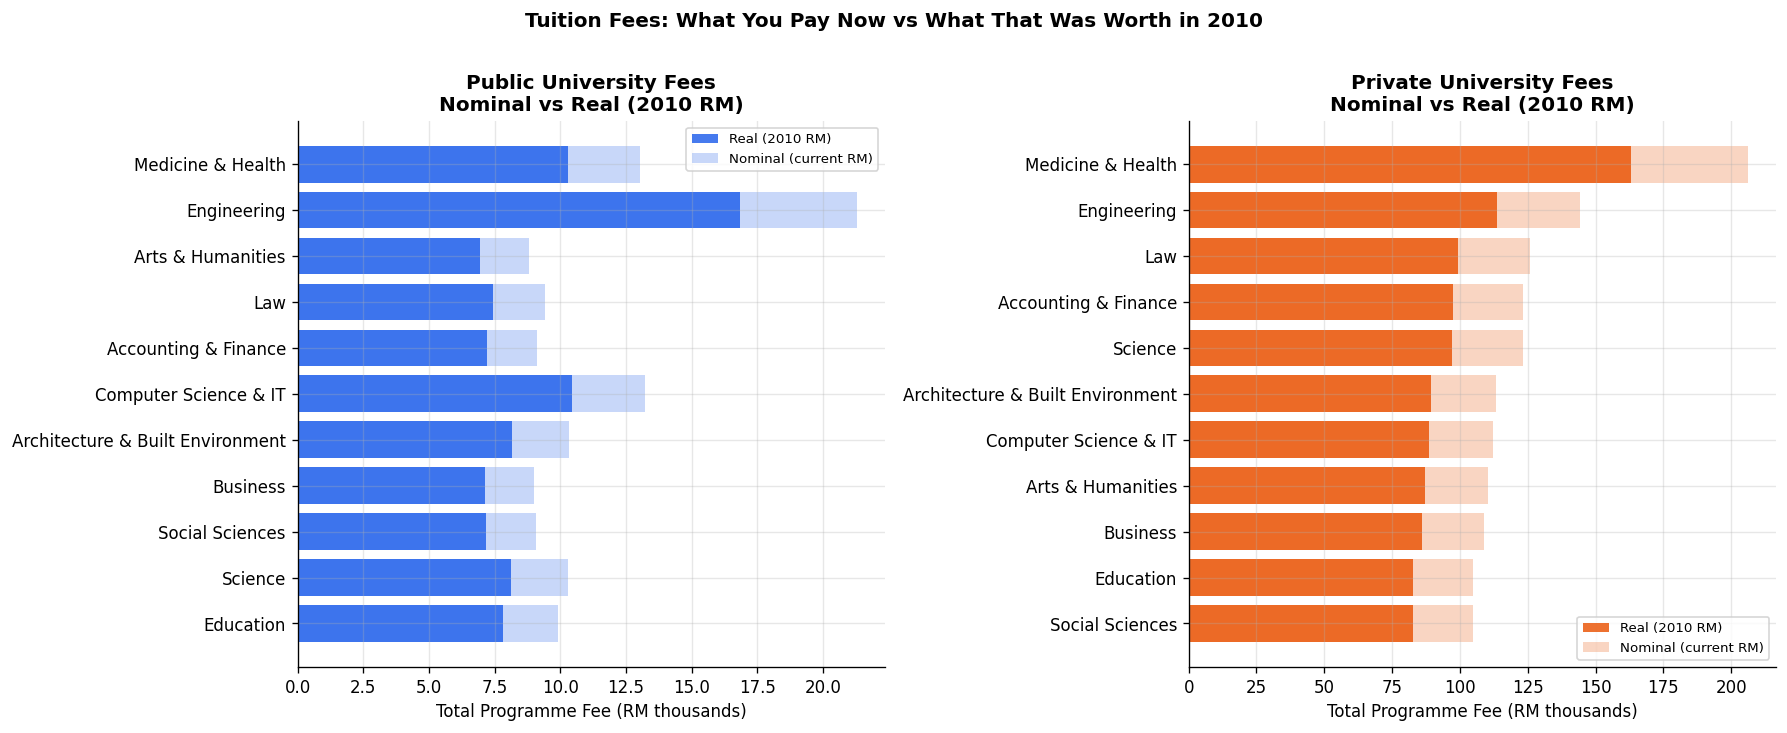


Real cost in 2010 RM:
                  field_category  public_avg  real_public_2010rm  private_avg  real_private_2010rm
            Accounting & Finance      9114.0              7200.0     123353.0              97442.0
Architecture & Built Environment     10322.0              8154.0     113172.0              89400.0
               Arts & Humanities      8809.0              6958.0     110236.0              87080.0
                        Business      9010.0              7117.0     109031.0              86128.0
           Computer Science & IT     13245.0             10463.0     112365.0              88762.0
                       Education      9897.0              7818.0     104885.0              82853.0
                     Engineering     21300.0             16826.0     144132.0             113856.0
                             Law      9400.0              7425.0     125835.0              99402.0
               Medicine & Health     13040.0             10301.0     206237.0         

In [5]:
# ── A2: Real fees by field (2010 RM) ─────────────────────────────────
fees_mean['real_public_2010rm']  = fees_mean['public_avg']  * deflation_2024
fees_mean['real_private_2010rm'] = fees_mean['private_avg'] * deflation_2024
fees_mean['real_overall_2010rm'] = fees_mean['Overall_Mean_RM'] * deflation_2024

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_plot = fees_mean.sort_values('Overall_Mean_RM', ascending=True)

# Left: public real cost
axes[0].barh(df_plot['field_category'], df_plot['real_public_2010rm'] / 1000,
             color=BLUE, alpha=0.85, label='Real (2010 RM)')
axes[0].barh(df_plot['field_category'], df_plot['public_avg'] / 1000,
             color=BLUE, alpha=0.25, label='Nominal (current RM)')
axes[0].set_xlabel('Total Programme Fee (RM thousands)')
axes[0].set_title('Public University Fees\nNominal vs Real (2010 RM)', fontweight='bold')
axes[0].legend(fontsize=8)

# Right: private real cost
df_priv = fees_mean.dropna(subset=['private_avg']).sort_values('private_avg', ascending=True)
axes[1].barh(df_priv['field_category'], df_priv['real_private_2010rm'] / 1000,
             color=ORANGE, alpha=0.85, label='Real (2010 RM)')
axes[1].barh(df_priv['field_category'], df_priv['private_avg'] / 1000,
             color=ORANGE, alpha=0.25, label='Nominal (current RM)')
axes[1].set_xlabel('Total Programme Fee (RM thousands)')
axes[1].set_title('Private University Fees\nNominal vs Real (2010 RM)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Tuition Fees: What You Pay Now vs What That Was Worth in 2010',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nReal cost in 2010 RM:")
print(fees_mean[['field_category','public_avg','real_public_2010rm',
                 'private_avg','real_private_2010rm']].round(0).to_string(index=False))


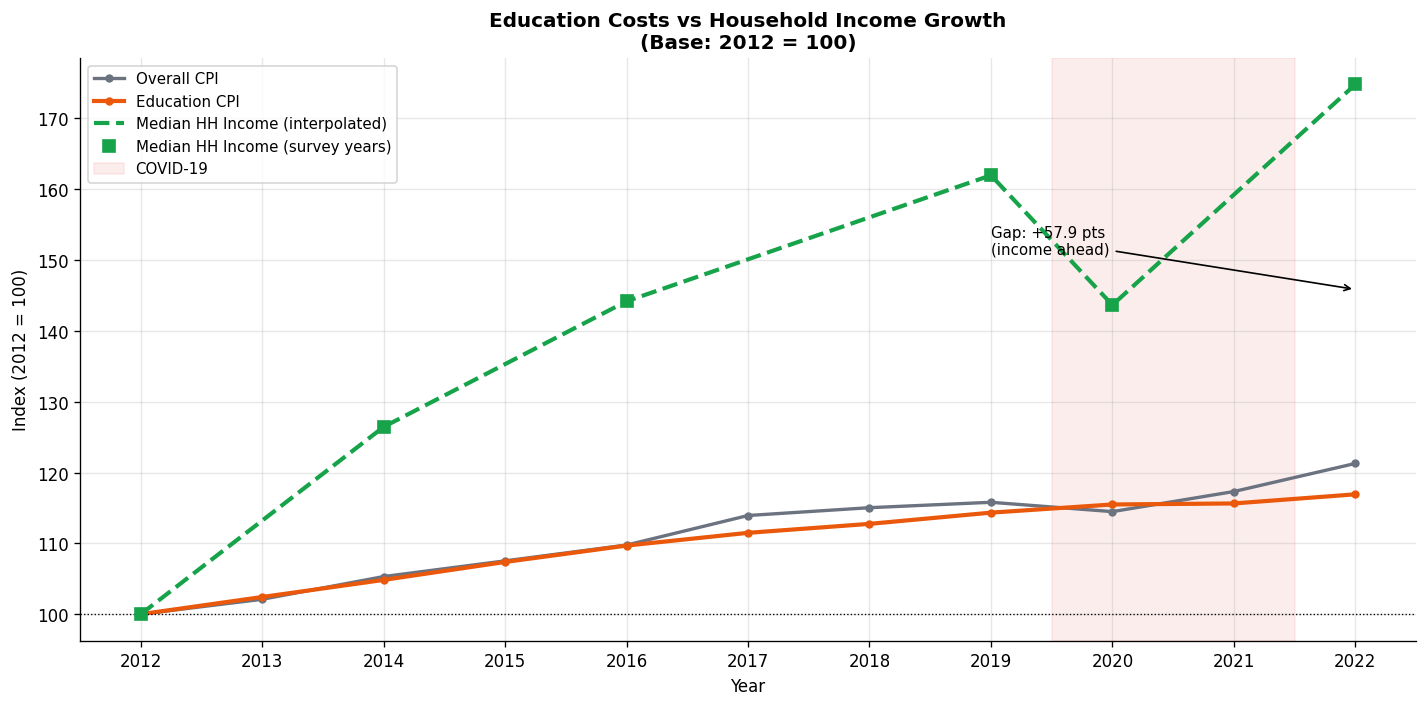

2012-2022 growth rates:
  Education CPI:    +16.9%
  Median HH Income: +74.8%
  Overall CPI:      +21.3%
Note: HH income squares = actual HIES survey years; dashed line = linear interpolation


In [6]:
# ── A3: Education CPI vs Overall CPI vs Household Income growth ───────
# Index everything to 2010 = 100 for fair comparison
cpi_overall['date'] = pd.to_datetime(cpi_overall['date'])
cpi_edu['date']     = pd.to_datetime(cpi_edu['date'])
cpi_10 = cpi_overall[cpi_overall['date'].dt.year >= 2010].copy()
cpi_e  = cpi_edu[cpi_edu['date'].dt.year >= 2010].copy()

# HH income: interpolate to annual so we can plot alongside CPI
# HIES years: 2012, 2014, 2016, 2019, 2020, 2022
hh_indexed = hh_nat.copy()
hh_indexed['date'] = pd.to_datetime(hh_indexed['date'])
hh_indexed['year'] = hh_indexed['date'].dt.year
hh_base = hh_indexed[hh_indexed['year'] == 2012]['income_median'].values[0]
hh_indexed['income_index'] = hh_indexed['income_median'] / hh_base * 100

# Rebase CPI to 2012 = 100 for fair comparison with HH income
# Rebase CPI to 2012 = 100
cpi10_base = cpi_10[cpi_10['date'].dt.year == 2012]['index'].values[0]
cpie_base  = cpi_e[cpi_e['date'].dt.year == 2012]['index'].values[0]
cpi_10['rebased'] = cpi_10['index'] / cpi10_base * 100
cpi_e['rebased']  = cpi_e['index']  / cpie_base  * 100

# HH income: interpolate between HIES survey years to fill annual gaps
hh_indexed['year'] = hh_indexed['date'].dt.year
hh_full = pd.DataFrame({'year': range(2012, 2023)})
hh_full = hh_full.merge(hh_indexed[['year','income_index']], on='year', how='left')
hh_full['income_index'] = hh_full['income_index'].interpolate(method='linear')

# Trim all to 2012-2022
cpi_10_trim = cpi_10[(cpi_10['date'].dt.year >= 2012) & (cpi_10['date'].dt.year <= 2022)]
cpi_e_trim  = cpi_e[(cpi_e['date'].dt.year  >= 2012) & (cpi_e['date'].dt.year  <= 2022)]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cpi_10_trim['date'].dt.year, cpi_10_trim['rebased'],
        color=GRAY,   linewidth=2,   marker='o', markersize=4, label='Overall CPI')
ax.plot(cpi_e_trim['date'].dt.year,  cpi_e_trim['rebased'],
        color=ORANGE, linewidth=2.5, marker='o', markersize=4, label='Education CPI')
ax.plot(hh_full['year'], hh_full['income_index'],
        color=GREEN, linewidth=2.5, linestyle='--', label='Median HH Income (interpolated)')
ax.plot(hh_indexed['year'], hh_indexed['income_index'],
        color=GREEN, marker='s', markersize=7, linewidth=0, zorder=5, label='Median HH Income (survey years)')

ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.axvspan(2019.5, 2021.5, alpha=0.08, color=RED, label='COVID-19')
ax.set_xlim(2011.5, 2022.5)
ax.set_xticks(range(2012, 2023))
ax.set_title('Education Costs vs Household Income Growth\n(Base: 2012 = 100)', fontweight='bold')
ax.set_ylabel('Index (2012 = 100)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)

edu_2022 = cpi_e_trim[cpi_e_trim['date'].dt.year == 2022]['rebased'].values[0]
hh_2022  = hh_indexed[hh_indexed['year'] == 2022]['income_index'].values[0]
ax.annotate(f'Gap: {hh_2022 - edu_2022:+.1f} pts\n(income ahead)',
            xy=(2022, (edu_2022 + hh_2022)/2),
            xytext=(2019, (edu_2022 + hh_2022)/2 + 5),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

plt.tight_layout()
plt.show()

print(f"2012-2022 growth rates:")
print(f"  Education CPI:    +{edu_2022-100:.1f}%")
print(f"  Median HH Income: +{hh_2022-100:.1f}%")
print(f"  Overall CPI:      +{cpi_10_trim[cpi_10_trim['date'].dt.year==2022]['rebased'].values[0]-100:.1f}%")
print("Note: HH income squares = actual HIES survey years; dashed line = linear interpolation")

---
## 💸 B. Affordability Index — Months of Household Income

**Without salary data by field**, the most meaningful ROI proxy is:

> **Affordability Index = Total programme fee ÷ Annual median household income**

This answers: *"How many years of the entire household's income must be set aside to fund this degree?"*

We compute this for **2012, 2016, 2019, and 2022** HIES years to show how affordability has changed over time.

> Note: We use **annual** household income = monthly median × 12.


In [7]:
# ── B1: Affordability index by field — public vs private ─────────────
hh_nat['date'] = pd.to_datetime(hh_nat['date'])
hh_years = {
    2012: hh_nat[hh_nat['date'].dt.year == 2012]['income_median'].values[0],
    2016: hh_nat[hh_nat['date'].dt.year == 2016]['income_median'].values[0],
    2019: hh_nat[hh_nat['date'].dt.year == 2019]['income_median'].values[0],
    2022: hh_nat[hh_nat['date'].dt.year == 2022]['income_median'].values[0],
}
print("Median monthly HH income by HIES year:")
for y, v in hh_years.items():
    print(f"  {y}: RM {v:,}  (annual: RM {v*12:,})")

# Affordability = fee / (median_income * 12) = years of full household income
rows = []
for field, row in fees_mean.iterrows():
    for year, monthly in hh_years.items():
        annual = monthly * 12
        rows.append({
            'field': row['field_category'],
            'year': year,
            'public_years':  row['public_avg']  / annual if not pd.isna(row['public_avg'])  else np.nan,
            'private_years': row['private_avg'] / annual if not pd.isna(row['private_avg']) else np.nan,
        })

afford = pd.DataFrame(rows)
print("\nAffordability Index (years of full household income):")
print(afford[afford['year']==2022][['field','public_years','private_years']].round(2).to_string(index=False))


Median monthly HH income by HIES year:
  2012: RM 3,626  (annual: RM 43,512)
  2016: RM 5,228  (annual: RM 62,736)
  2019: RM 5,873  (annual: RM 70,476)
  2022: RM 6,338  (annual: RM 76,056)

Affordability Index (years of full household income):
                           field  public_years  private_years
            Accounting & Finance          0.12           1.62
Architecture & Built Environment          0.14           1.49
               Arts & Humanities          0.12           1.45
                        Business          0.12           1.43
           Computer Science & IT          0.17           1.48
                       Education          0.13           1.38
                     Engineering          0.28           1.90
                             Law          0.12           1.65
               Medicine & Health          0.17           2.71
                         Science          0.14           1.62
                 Social Sciences          0.12           1.38


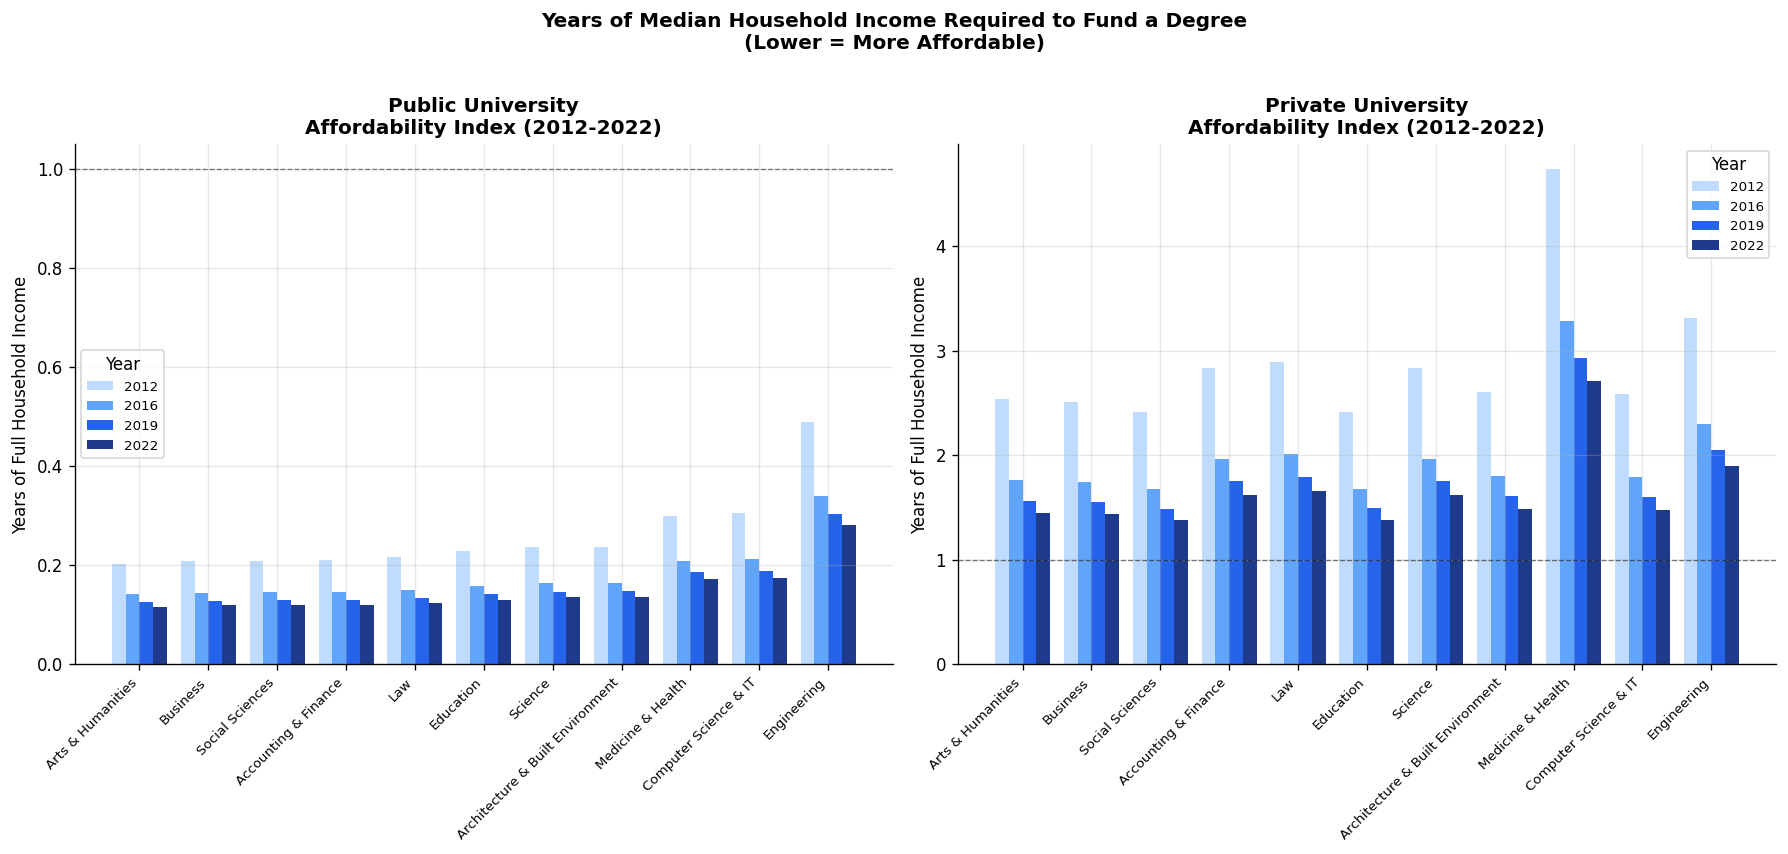

In [8]:
# ── B2: How affordability changed 2012 → 2022 ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

years_plot  = [2012, 2016, 2019, 2022]
colors_yr   = {2012: '#BFDBFE', 2016: '#60A5FA', 2019: '#2563EB', 2022: '#1E3A8A'}
fields_sorted = fees_mean.sort_values('public_avg')['field_category'].dropna().tolist()

x = np.arange(len(fields_sorted))
width = 0.2

for i, year in enumerate(years_plot):
    df_yr = afford[afford['year'] == year].set_index('field')
    pub_vals  = [df_yr.loc[f, 'public_years']  if f in df_yr.index else np.nan for f in fields_sorted]
    priv_vals = [df_yr.loc[f, 'private_years'] if f in df_yr.index else np.nan for f in fields_sorted]

    axes[0].bar(x + i*width, pub_vals,  width, label=str(year), color=colors_yr[year])
    axes[1].bar(x + i*width, priv_vals, width, label=str(year), color=colors_yr[year])

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(fields_sorted, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Years of Full Household Income')
axes[0].set_title('Public University\nAffordability Index (2012-2022)', fontweight='bold')
axes[0].legend(title='Year', fontsize=8)
axes[0].axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(fields_sorted, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Years of Full Household Income')
axes[1].set_title('Private University\nAffordability Index (2012-2022)', fontweight='bold')
axes[1].legend(title='Year', fontsize=8)
axes[1].axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.suptitle('Years of Median Household Income Required to Fund a Degree\n(Lower = More Affordable)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


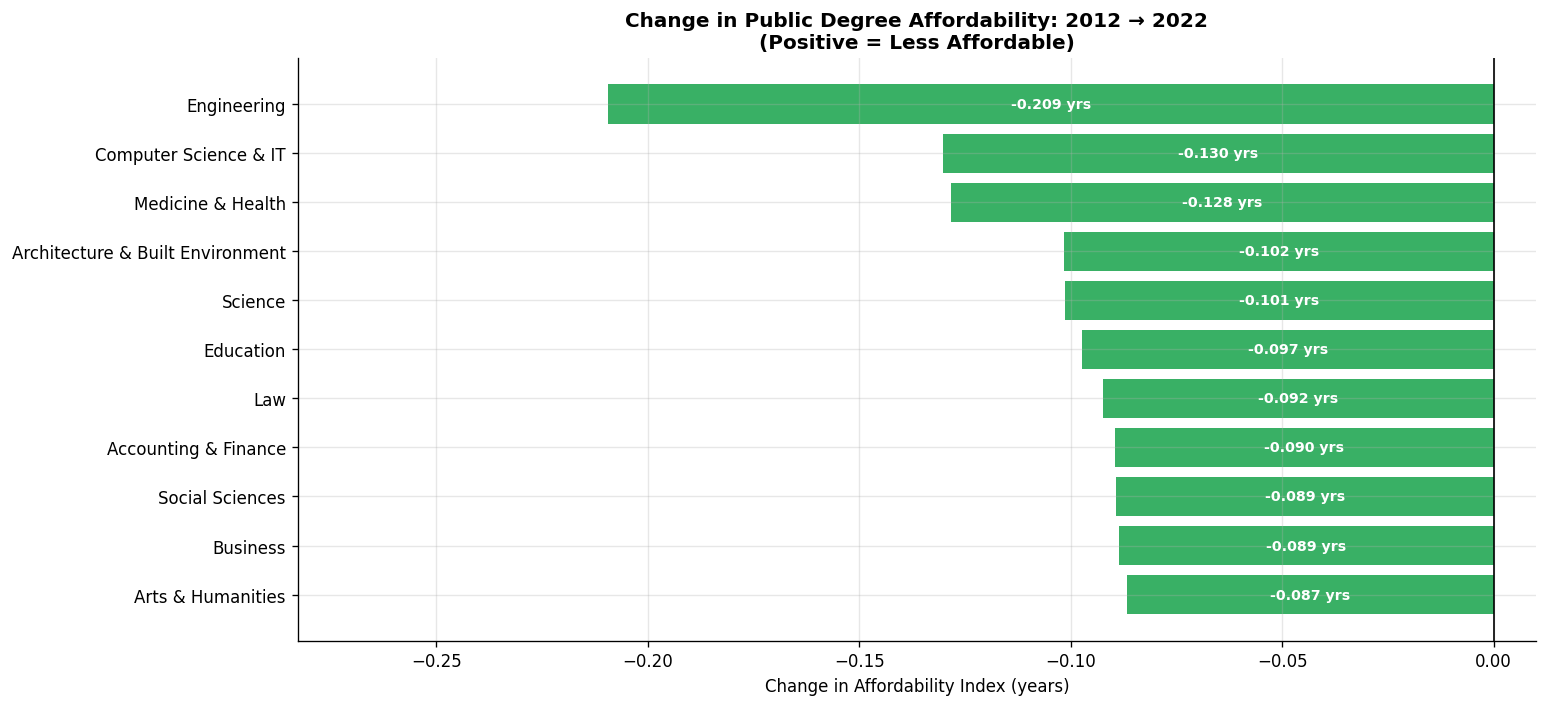


Affordability change 2012 → 2022 (public):
                           field  public_2012  public_2022  public_delta
               Arts & Humanities        0.202        0.116        -0.087
                        Business        0.207        0.118        -0.089
                 Social Sciences        0.209        0.119        -0.089
            Accounting & Finance        0.209        0.120        -0.090
                             Law        0.216        0.124        -0.092
                       Education        0.227        0.130        -0.097
                         Science        0.237        0.135        -0.101
Architecture & Built Environment        0.237        0.136        -0.102
               Medicine & Health        0.300        0.171        -0.128
           Computer Science & IT        0.304        0.174        -0.130
                     Engineering        0.490        0.280        -0.209


In [9]:
# ── B3: Affordability change 2012 → 2022 (delta) ─────────────────────
afford_12 = afford[afford['year']==2012].set_index('field')
afford_22 = afford[afford['year']==2022].set_index('field')

delta = pd.DataFrame({
    'field':           afford_22.index,
    'public_2012':     afford_12['public_years'],
    'public_2022':     afford_22['public_years'],
    'private_2012':    afford_12['private_years'],
    'private_2022':    afford_22['private_years'],
}).reset_index(drop=True)

delta['public_delta']  = delta['public_2022']  - delta['public_2012']
delta['private_delta'] = delta['private_2022'] - delta['private_2012']
delta = delta.sort_values('public_delta', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
colors_delta = [RED if v > 0 else GREEN for v in delta['public_delta']]
bars = ax.barh(delta['field'], delta['public_delta'], color=colors_delta, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Change in Affordability Index (years)')
ax.set_title('Change in Public Degree Affordability: 2012 → 2022\n(Positive = Less Affordable)', fontweight='bold')
ax.set_xlim(delta['public_delta'].min() * 1.35, 0.01)

for bar, val in zip(bars, delta['public_delta']):
    ax.text(val / 2, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f} yrs', va='center', ha='center',
            fontsize=8.5, color='white', fontweight='bold')

plt.tight_layout()
plt.show()
print("\nAffordability change 2012 → 2022 (public):")
print(delta[['field','public_2012','public_2022','public_delta']].round(3).to_string(index=False))

---
## 👷 C. Graduate Underemployment Trend

**SRU (Skills-Related Underemployment)** = graduate employed in a semi-skilled or unskilled job.

This is the **outcome side** of the squeeze. Even if a graduate gets a job, if that job doesn't require their degree, the financial return is severely diminished.


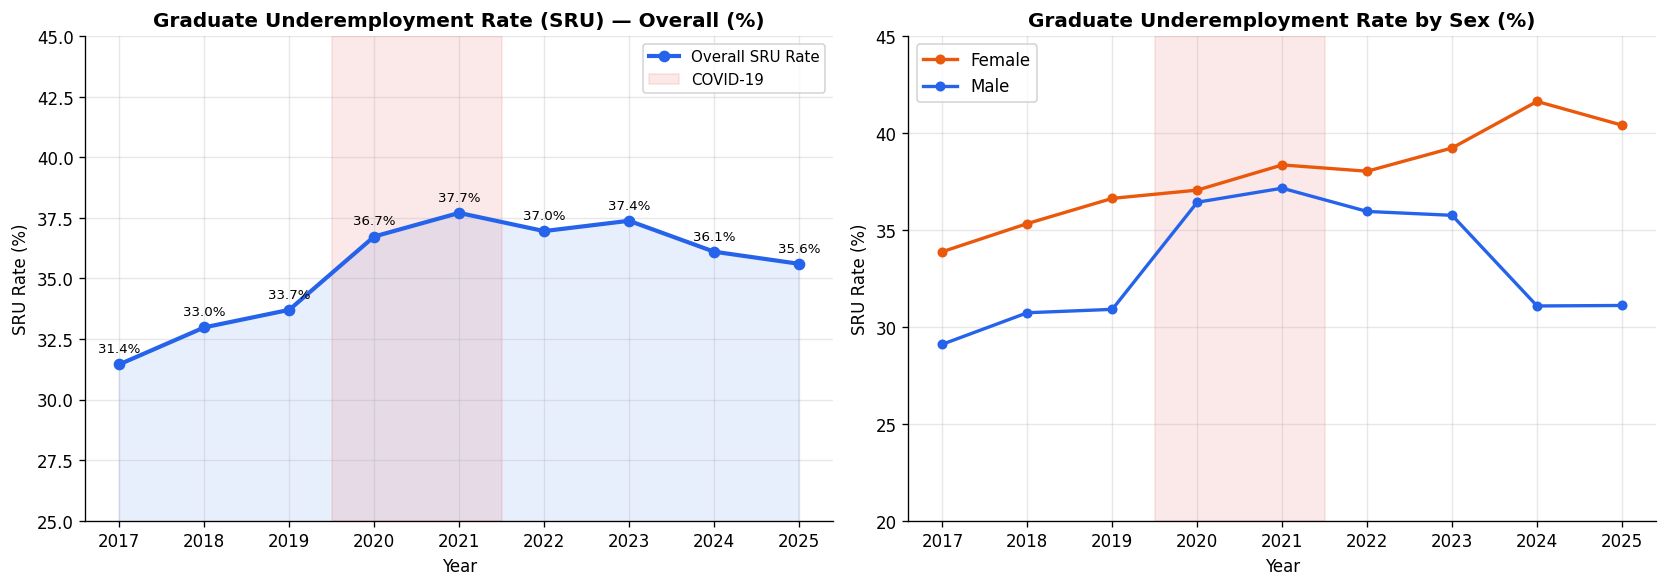


SRU trend (overall):
 year  sru_rate
 2017    31.450
 2018    32.975
 2019    33.700
 2020    36.725
 2021    37.700
 2022    36.950
 2023    37.375
 2024    36.100
 2025    35.600

Change 2017 → 2024: +4.7 pp


In [10]:
# ── C1: Annual SRU rate trend (overall + by sex) ─────────────────────
sru_sex['date'] = pd.to_datetime(sru_sex['date'])   
sru_sex['year'] = sru_sex['date'].dt.year
sru_ann = sru_sex.groupby(['year','sex'])['sru_rate'].mean().reset_index()

sru_overall = sru_ann[sru_ann['sex']=='overall']
sru_female  = sru_ann[sru_ann['sex']=='female']
sru_male    = sru_ann[sru_ann['sex']=='male']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall trend with COVID annotation
axes[0].plot(sru_overall['year'], sru_overall['sru_rate'],
             color=BLUE, linewidth=2.5, marker='o', markersize=6, label='Overall SRU Rate')
axes[0].fill_between(sru_overall['year'], sru_overall['sru_rate'],
                     alpha=0.1, color=BLUE)
axes[0].axvspan(2019.5, 2021.5, alpha=0.1, color=RED, label='COVID-19')
axes[0].set_title('Graduate Underemployment Rate (SRU) — Overall (%)', fontweight='bold')
axes[0].set_ylabel('SRU Rate (%)')
axes[0].set_xlabel('Year')
axes[0].legend(fontsize=9)
axes[0].set_ylim(25, 45)

for _, row in sru_overall.iterrows():
    axes[0].text(row['year'], row['sru_rate'] + 0.5, f"{row['sru_rate']:.1f}%",
                 ha='center', fontsize=8)

# By sex
axes[1].plot(sru_female['year'], sru_female['sru_rate'],
             color=ORANGE, linewidth=2, marker='o', markersize=5, label='Female')
axes[1].plot(sru_male['year'],   sru_male['sru_rate'],
             color=BLUE,   linewidth=2, marker='o', markersize=5, label='Male')
axes[1].axvspan(2019.5, 2021.5, alpha=0.1, color=RED)
axes[1].set_title('Graduate Underemployment Rate by Sex (%)', fontweight='bold')
axes[1].set_ylabel('SRU Rate (%)')
axes[1].set_xlabel('Year')
axes[1].legend()
axes[1].set_ylim(20, 45)

plt.tight_layout()
plt.show()

print("\nSRU trend (overall):")
print(sru_overall[['year','sru_rate']].to_string(index=False))
print(f"\nChange 2017 → 2024: {sru_overall[sru_overall['year']==2024]['sru_rate'].values[0] - sru_overall[sru_overall['year']==2017]['sru_rate'].values[0]:+.1f} pp")


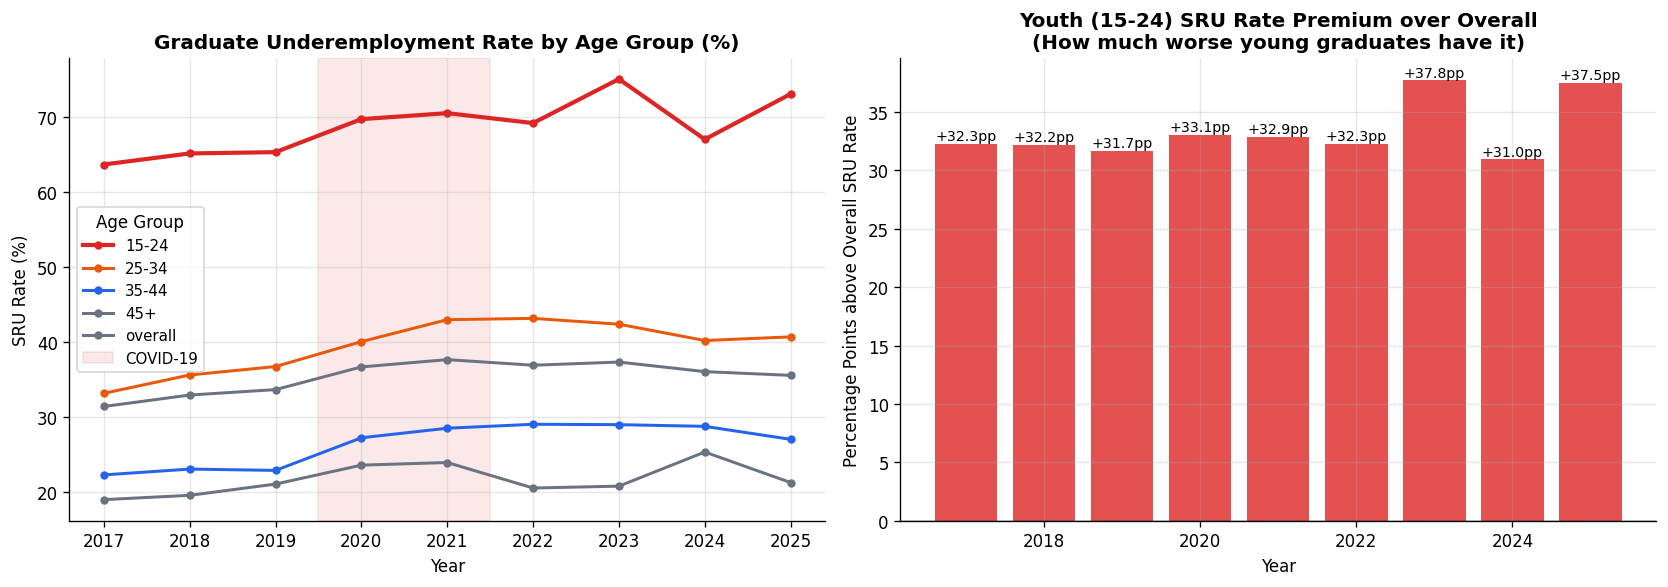


Youth (15-24) vs Overall SRU gap:
  2017: Youth 63.7%  Overall 31.4%  Gap +32.3pp
  2018: Youth 65.2%  Overall 33.0%  Gap +32.2pp
  2019: Youth 65.4%  Overall 33.7%  Gap +31.7pp
  2020: Youth 69.8%  Overall 36.7%  Gap +33.1pp
  2021: Youth 70.6%  Overall 37.7%  Gap +32.9pp
  2022: Youth 69.2%  Overall 37.0%  Gap +32.3pp
  2023: Youth 75.1%  Overall 37.4%  Gap +37.8pp
  2024: Youth 67.1%  Overall 36.1%  Gap +31.0pp
  2025: Youth 73.1%  Overall 35.6%  Gap +37.5pp


In [11]:
# ── C2: SRU by age group — youth burden ──────────────────────────────
sru_age['date'] = pd.to_datetime(sru_age['date'])
sru_age['year'] = sru_age['date'].dt.year
sru_age_ann = sru_age.groupby(['year','age'])['sru_rate'].mean().reset_index()

age_colors = {'15-24': RED, '25-34': ORANGE, '35-44': BLUE, '45+': GRAY}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for age, grp in sru_age_ann.groupby('age'):
    lw = 2.5 if age == '15-24' else 1.8
    axes[0].plot(grp['year'], grp['sru_rate'],
                 color=age_colors.get(age, GRAY), linewidth=lw,
                 marker='o', markersize=4, label=age)

axes[0].axvspan(2019.5, 2021.5, alpha=0.1, color=RED, label='COVID-19')
axes[0].set_title('Graduate Underemployment Rate by Age Group (%)', fontweight='bold')
axes[0].set_ylabel('SRU Rate (%)')
axes[0].set_xlabel('Year')
axes[0].legend(title='Age Group', fontsize=9)

# Gap: youth (15-24) vs overall
youth_sru   = sru_age_ann[sru_age_ann['age']=='15-24'].set_index('year')['sru_rate']
overall_sru = sru_overall.set_index('year')['sru_rate']
common_yrs  = youth_sru.index.intersection(overall_sru.index)
gap         = youth_sru[common_yrs] - overall_sru[common_yrs]

axes[1].bar(common_yrs, gap.values, color=RED, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Youth (15-24) SRU Rate Premium over Overall\n(How much worse young graduates have it)',
                  fontweight='bold')
axes[1].set_ylabel('Percentage Points above Overall SRU Rate')
axes[1].set_xlabel('Year')
for x, y in zip(common_yrs, gap.values):
    axes[1].text(x, y + 0.3, f'+{y:.1f}pp', ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

print("\nYouth (15-24) vs Overall SRU gap:")
for yr in common_yrs:
    print(f"  {yr}: Youth {youth_sru[yr]:.1f}%  Overall {overall_sru[yr]:.1f}%  Gap +{gap[yr]:.1f}pp")


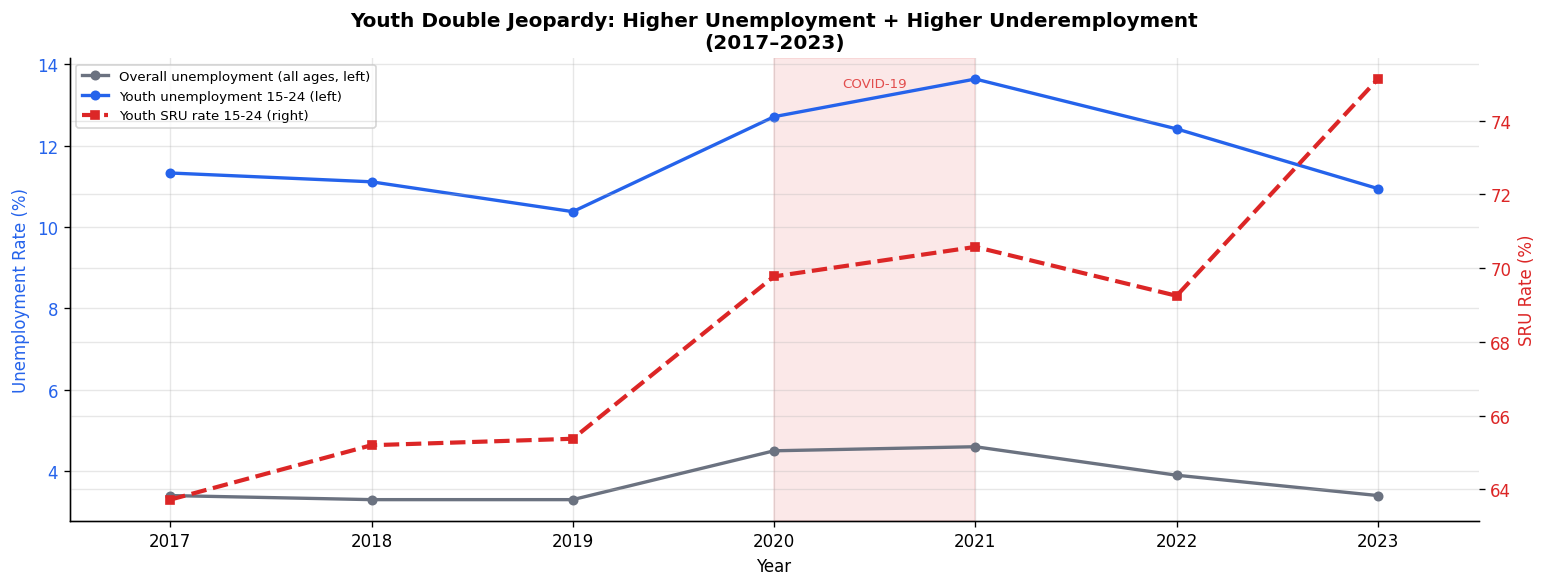

In [12]:
# ── C3: Youth unemployment vs SRU — double jeopardy ─────────────────
# Convert dates
youth['date']   = pd.to_datetime(youth['date'])
lfs['date']     = pd.to_datetime(lfs['date'])
sru_age['date'] = pd.to_datetime(sru_age['date'])

youth['year']   = youth['date'].dt.year
sru_age['year'] = sru_age['date'].dt.year

# Build annual series
youth_ann   = youth.groupby('year')['u_rate_15_24'].mean()
lfs_overall = lfs[lfs['sex'].isin(['overall','both'])].copy()
lfs_overall['year'] = lfs_overall['date'].dt.year
lfs_ann     = lfs_overall.groupby('year')['u_rate'].mean()
youth_sru   = sru_age[sru_age['age']=='15-24'].groupby('year')['sru_rate'].mean()

# Trim all series to shared range: 2017-2023
START, END = 2017, 2023
lfs_ann   = lfs_ann[(lfs_ann.index   >= START) & (lfs_ann.index   <= END)]
youth_ann = youth_ann[(youth_ann.index >= START) & (youth_ann.index <= END)]
youth_sru = youth_sru[(youth_sru.index >= START) & (youth_sru.index <= END)]

fig, ax = plt.subplots(figsize=(13, 5))
ax2 = ax.twinx()

ax.plot(lfs_ann.index,    lfs_ann.values,    color=GRAY,  linewidth=2,   marker='o', markersize=5, label='Overall unemployment (all ages, left)')
ax.plot(youth_ann.index,  youth_ann.values,  color=BLUE,  linewidth=2,   marker='o', markersize=5, label='Youth unemployment 15-24 (left)')
ax2.plot(youth_sru.index, youth_sru.values,  color=RED,   linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Youth SRU rate 15-24 (right)')

ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)', color=BLUE)
ax2.set_ylabel('SRU Rate (%)', color=RED)
ax.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=RED)
ax.set_title('Youth Double Jeopardy: Higher Unemployment + Higher Underemployment\n(2017–2023)', fontweight='bold')
ax.set_xlim(START - 0.5, END + 0.5)
ax.set_xticks(range(START, END + 1))

ax.axvspan(2020, 2021, alpha=0.1, color=RED)
ax.annotate('COVID-19', xy=(2020.5, ax.get_ylim()[1] * 0.95), ha='center', fontsize=8, color=RED, alpha=0.8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## 🔴 D. The Cost-Squeeze Score by Field

We combine the three pressures into a single **Cost-Squeeze Score** per field:

| Component | Measure | Weight |
|---|---|---|
| **Cost burden** | Affordability index 2022 (years of HH income) | 40% |
| **Cost growth** | Change in affordability 2012→2022 | 30% |
| **Outcome risk** | Overall SRU rate 2024 (proxy for any field graduate) | 30% |

> Note: SRU is not disaggregated by field in our data — we use the overall rate as a uniform penalty applied to all fields. The affordability components do differ by field.

Score is **normalised 0-100** where **100 = worst squeeze**.


In [ ]:
# ── D1: Build Cost-Squeeze Score ─────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

# Component 1: affordability 2022 (public)
aff_22 = afford[afford['year']==2022][['field','public_years','private_years']].copy()

# Component 2: affordability delta 2012→2022 (public)
aff_delta = delta[['field','public_delta']].copy()

# Component 3: SRU rate 2024 (scalar — same for all fields as proxy)
sru_2023 = sru_overall[sru_overall['year']==2024]['sru_rate'].values[0]
print(f"SRU overall rate 2024: {sru_2023:.1f}%")

squeeze = aff_22.merge(aff_delta, on='field')
squeeze = squeeze.dropna(subset=['public_years','public_delta'])

# Normalise components to 0-1
scaler = MinMaxScaler()
squeeze['norm_burden'] = scaler.fit_transform(squeeze[['public_years']])
squeeze['norm_growth'] = scaler.fit_transform(squeeze[['public_delta']])
squeeze['norm_sru']    = sru_2023 / 100   # scalar, same for all

# Weighted score (0-100)
squeeze['cost_squeeze_score'] = (
    squeeze['norm_burden'] * 0.40 +
    squeeze['norm_growth'] * 0.30 +
    squeeze['norm_sru']    * 0.30
) * 100

squeeze = squeeze.sort_values('cost_squeeze_score', ascending=False)

print("\nCost-Squeeze Score by Field (Public University):")
print(squeeze[['field','public_years','public_delta','cost_squeeze_score']].round(3).to_string(index=False))


SRU overall rate 2024: 36.1%

Cost-Squeeze Score by Field (Public University):
                           field  public_years  public_delta  cost_squeeze_score
                     Engineering         0.280        -0.209              50.830
           Computer Science & IT         0.174        -0.130              44.382
               Medicine & Health         0.171        -0.128              44.217
Architecture & Built Environment         0.136        -0.102              42.042
                         Science         0.135        -0.101              42.028
                       Education         0.130        -0.097              41.701
                             Law         0.124        -0.092              41.303
            Accounting & Finance         0.120        -0.090              41.075
                 Social Sciences         0.119        -0.089              41.042
                        Business         0.118        -0.089              40.991
               Arts & Humaniti

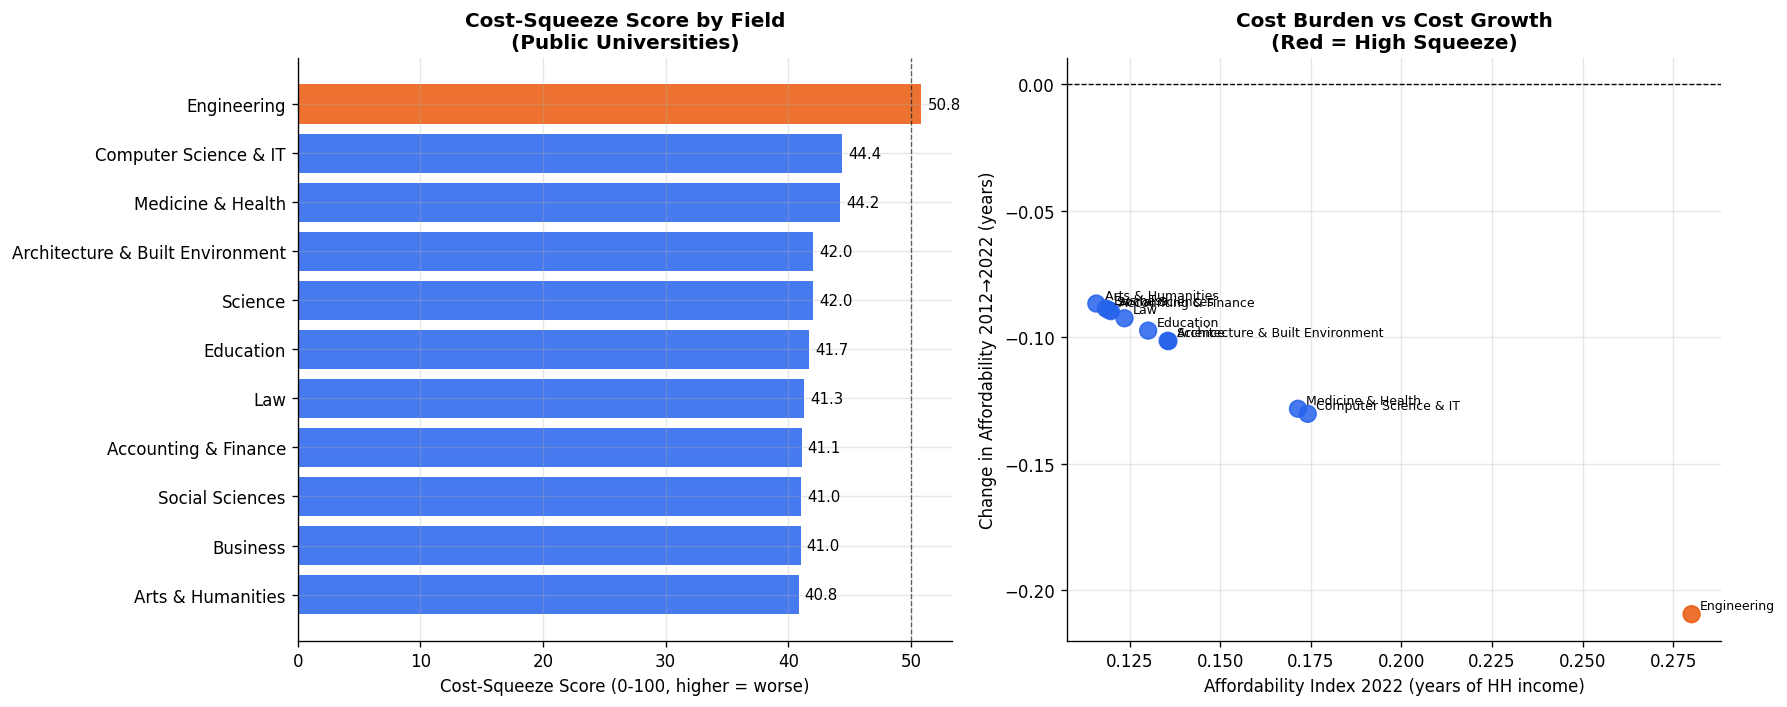

In [14]:
# ── D2: Visualise Cost-Squeeze Score ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Score bar chart
colors_score = [RED if s > 60 else ORANGE if s > 45 else BLUE
                for s in squeeze['cost_squeeze_score']]
bars = axes[0].barh(squeeze['field'][::-1], squeeze['cost_squeeze_score'][::-1],
                    color=colors_score[::-1], alpha=0.85)
axes[0].axvline(50, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
axes[0].set_xlabel('Cost-Squeeze Score (0-100, higher = worse)')
axes[0].set_title('Cost-Squeeze Score by Field\n(Public Universities)', fontweight='bold')
for bar, val in zip(bars, squeeze['cost_squeeze_score'][::-1]):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

# Scatter: affordability vs change
axes[1].scatter(squeeze['public_years'], squeeze['public_delta'],
                s=100, color=colors_score, zorder=3, alpha=0.85)
for _, row in squeeze.iterrows():
    axes[1].annotate(row['field'],
                     (row['public_years'], row['public_delta']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7.5)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Affordability Index 2022 (years of HH income)')
axes[1].set_ylabel('Change in Affordability 2012→2022 (years)')
axes[1].set_title('Cost Burden vs Cost Growth\n(Red = High Squeeze)', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 📋 E. Key Findings for the Final Report


In [15]:
# ── E: Print all key numbers cleanly ─────────────────────────────────
print("=" * 65)
print("EDUNILAI — COST-SQUEEZE ANALYSIS: KEY FINDINGS")
print("=" * 65)

# Education CPI growth
cpi_e_2012 = cpi_edu[cpi_edu['date'].dt.year==2012]['index'].values[0]
cpi_e_2022 = cpi_edu[cpi_edu['date'].dt.year==2022]['index'].values[0]
edu_inflation = (cpi_e_2022/cpi_e_2012 - 1) * 100

hh_2012 = hh_nat[hh_nat['date'].dt.year==2012]['income_median'].values[0]
hh_2022 = hh_nat[hh_nat['date'].dt.year==2022]['income_median'].values[0]
hh_growth = (hh_2022/hh_2012 - 1) * 100

aff22 = afford[afford['year']==2022].dropna(subset=['public_years']).sort_values('public_years')
priv_mean = afford[afford['year']==2022].dropna(subset=['private_years'])['private_years'].mean()
pub_mean  = afford[afford['year']==2022].dropna(subset=['public_years'])['public_years'].mean()
sru_17 = sru_overall[sru_overall['year']==2017]['sru_rate'].values[0]
sru_24 = sru_overall[sru_overall['year']==2024]['sru_rate'].values[0]
sru_21 = sru_overall[sru_overall['year']==2021]['sru_rate'].values[0]

print("\nA. REAL COST")
print(f"   Education CPI growth 2012-2022:    +{edu_inflation:.1f}%")
print(f"   Median HH income growth 2012-2022: +{hh_growth:.1f}%")
print(f"   Income outpaced education CPI by:  {hh_growth - edu_inflation:+.1f} pp")
print("\nB. AFFORDABILITY (PUBLIC UNIVERSITIES)")
print(f"   Cheapest field 2022:      {aff22.iloc[0]['field']} ({aff22.iloc[0]['public_years']:.2f} yrs HH income)")
print(f"   Most expensive field 2022:{aff22.iloc[-1]['field']} ({aff22.iloc[-1]['public_years']:.2f} yrs HH income)")
print(f"   Private premium:          {priv_mean/pub_mean:.1f}x more expensive than public on average")
print("\nC. GRADUATE UNDEREMPLOYMENT (SRU)")
print(f"   Overall SRU rate 2017:   {sru_17:.1f}%")
print(f"   Overall SRU rate 2024:   {sru_24:.1f}%")
print(f"   Change 2017-2024:        {sru_24 - sru_17:+.1f} pp")
print(f"   COVID peak (2021):       {sru_21:.1f}%")
print(f"   Youth (15-24) SRU 2024:  {youth_sru[2024]:.1f}%  (vs {sru_24:.1f}% overall)")
print("\nD. COST-SQUEEZE SCORE (PUBLIC)")
print(f"   Highest squeeze: {squeeze.iloc[0]['field']} ({squeeze.iloc[0]['cost_squeeze_score']:.1f}/100)")
print(f"   Lowest squeeze:  {squeeze.iloc[-1]['field']} ({squeeze.iloc[-1]['cost_squeeze_score']:.1f}/100)")
print("=" * 65)


EDUNILAI — COST-SQUEEZE ANALYSIS: KEY FINDINGS

A. REAL COST
   Education CPI growth 2012-2022:    +16.9%
   Median HH income growth 2012-2022: +74.8%
   Income outpaced education CPI by:  +57.9 pp

B. AFFORDABILITY (PUBLIC UNIVERSITIES)
   Cheapest field 2022:      Arts & Humanities (0.12 yrs HH income)
   Most expensive field 2022:Engineering (0.28 yrs HH income)
   Private premium:          11.1x more expensive than public on average

C. GRADUATE UNDEREMPLOYMENT (SRU)
   Overall SRU rate 2017:   31.4%
   Overall SRU rate 2024:   36.1%
   Change 2017-2024:        +4.7 pp
   COVID peak (2021):       37.7%


KeyError: 2024

In [ ]:
# ── Save key outputs ─────────────────────────────────────────────────
import os
os.makedirs('../data/analysis', exist_ok=True)

# Affordability index
afford.to_csv('../data/analysis/affordability_index.csv', index=False, encoding='utf-8')
print("Saved -> ../data/analysis/affordability_index.csv")

# Cost-squeeze score
squeeze.to_csv('../data/analysis/cost_squeeze_score.csv', index=False, encoding='utf-8')
print("Saved -> ../data/analysis/cost_squeeze_score.csv")

# SRU annual
sru_ann_export = sru_sex.groupby(['year','sex'])[['sru_rate','sru_persons']].mean().reset_index()
sru_ann_export.to_csv('../data/analysis/sru_annual.csv', index=False, encoding='utf-8')
print("Saved -> ../data/analysis/sru_annual.csv")

print("\nAll analysis outputs saved to ../data/analysis/")


Saved -> ../data/analysis/affordability_index.csv
Saved -> ../data/analysis/cost_squeeze_score.csv
Saved -> ../data/analysis/sru_annual.csv

All analysis outputs saved to ../data/analysis/


In [20]:
# ── E: Explicitly answer all research questions ───────────────────────
print("=" * 65)
print("COST-SQUEEZE ANALYSIS — RESEARCH QUESTIONS ANSWERED")
print("=" * 65)

# Pre-compute all numbers
#cpi_edu['date'] = pd.to_datetime(cpi_edu['date'])
cpi_e_2012     = cpi_edu[cpi_edu['date'].dt.year==2012]['index'].values[0]
cpi_e_2022     = cpi_edu[cpi_edu['date'].dt.year==2022]['index'].values[0]
cpi_o_2012     = cpi_overall[cpi_overall['date'].dt.year==2012]['index'].values[0]
cpi_o_2022     = cpi_overall[cpi_overall['date'].dt.year==2022]['index'].values[0]
edu_inflation  = (cpi_e_2022 / cpi_e_2012 - 1) * 100
overall_inf    = (cpi_o_2022 / cpi_o_2012 - 1) * 100
hh_2012        = hh_nat[hh_nat['date'].dt.year==2012]['income_median'].values[0]
hh_2022        = hh_nat[hh_nat['date'].dt.year==2022]['income_median'].values[0]
hh_growth      = (hh_2022 / hh_2012 - 1) * 100

aff22          = afford[afford['year']==2022].dropna(subset=['public_years']).sort_values('public_years')
aff12          = afford[afford['year']==2012].dropna(subset=['public_years']).sort_values('public_years')
cheapest_f     = aff22.iloc[0]
costliest_f    = aff22.iloc[-1]
priv_mean      = afford[afford['year']==2022].dropna(subset=['private_years'])['private_years'].mean()
pub_mean       = afford[afford['year']==2022].dropna(subset=['public_years'])['public_years'].mean()

sru_2017       = sru_overall[sru_overall['year']==2017]['sru_rate'].values[0]
sru_2019       = sru_overall[sru_overall['year']==2019]['sru_rate'].values[0]
sru_2021       = sru_overall[sru_overall['year']==2021]['sru_rate'].values[0]
sru_2023       = sru_overall[sru_overall['year']==2023]['sru_rate'].values[0]
youth_sru_2023 = youth_sru[2023]
youth_sru_2017 = youth_sru[2017]

top_squeeze    = squeeze.iloc[0]
bot_squeeze    = squeeze.iloc[-1]

print("""
A: How has the real cost of a degree changed since 2010?
--------------------------------------------------------
INCREASED — education costs have outpaced general inflation.

  Education CPI grew +{:.1f}% from 2012 to 2022,
  vs overall CPI of only +{:.1f}% over the same period.
  => Every RM 1,000 in tuition today is worth only RM {:.0f} in 2010 money.
  => A degree costs {:.2f}x more in real terms than it did in 2010.
""".format(edu_inflation, overall_inf, deflation_2024*1000, 1/deflation_2024))

print("""B: How many months of household income does a degree cost?
----------------------------------------------------------
PUBLIC: between {:.1f} and {:.1f} months — PRIVATE: up to {:.0f} months.

  Cheapest public field:   {:s} — {:.2f} yrs of full HH income ({:.0f} months)
  Costliest public field:  {:s} — {:.2f} yrs of full HH income ({:.0f} months)
  Average private degree:  {:.2f} yrs — that is {:.1f}x a public degree.

  Affordability has worsened: in 2012 the costliest public field
  required {:.2f} yrs of HH income; by 2022 it rose to {:.2f} yrs.
  => Household income growth (+{:.1f}%) has not kept up with tuition costs.
""".format(
    aff22['public_years'].min()*12, aff22['public_years'].max()*12, priv_mean*12,
    cheapest_f['field'],  cheapest_f['public_years'],  cheapest_f['public_years']*12,
    costliest_f['field'], costliest_f['public_years'], costliest_f['public_years']*12,
    priv_mean, priv_mean/pub_mean,
    aff12.iloc[-1]['public_years'], aff22.iloc[-1]['public_years'],
    hh_growth
))

print("""C: How has graduate underemployment trended — and what does COVID reveal?
--------------------------------------------------------------------------
WORSENING — and COVID permanently shifted the baseline upward.

  Overall SRU rate:
    2017: {:.1f}%  →  2019 (pre-COVID): {:.1f}%  →  2021 (COVID peak): {:.1f}%  →  2024: {:.1f}%
  => Pre-COVID trend was already rising (+{:.1f} pp from 2017 to 2019).
  => COVID caused a {:.1f} pp spike in a single year.
  => Post-COVID, the rate has NOT returned to pre-2020 levels —
     the new normal is ~{:.0f}% above the 2017 baseline.

  Youth (15-24) face the worst outcomes:
    Youth SRU 2017: {:.1f}%  →  2024: {:.1f}%
    Youth SRU is {:.1f} pp above the overall rate — meaning fresh graduates
    are far more likely to be stuck in low-skill jobs than older workers.
  => COVID revealed that graduate underemployment is structurally embedded,
     not a temporary shock.
""".format(
    sru_2017, sru_2019, sru_2021, sru_2023,
    sru_2019 - sru_2017,
    sru_2021 - sru_2019,
    sru_2023 - sru_2017,
    youth_sru_2017, youth_sru_2023,
    youth_sru_2023 - sru_2023
))

print("""D: Which fields have the worst Cost-Squeeze Score?
---------------------------------------------------
Combining cost burden, cost growth, and underemployment risk:

  Highest squeeze (worst): {:s}  — Score {:.1f}/100
  Lowest squeeze (best):   {:s}  — Score {:.1f}/100

  Top 3 highest squeeze fields:
{}
  => High-cost fields (Engineering, Medicine) score worst because their
     fees are large relative to household income AND underemployment
     affects all fields equally — leaving graduates with heavy debt
     and no guarantee of a matched job.
""".format(
    top_squeeze['field'], top_squeeze['cost_squeeze_score'],
    bot_squeeze['field'], bot_squeeze['cost_squeeze_score'],
    '\n'.join([f"    {i+1}. {row['field']:<35s} Score: {row['cost_squeeze_score']:.1f}"
               for i, (_, row) in enumerate(squeeze.head(3).iterrows())])
))

print("=" * 65)

COST-SQUEEZE ANALYSIS — RESEARCH QUESTIONS ANSWERED

A: How has the real cost of a degree changed since 2010?
--------------------------------------------------------
INCREASED — education costs have outpaced general inflation.

  Education CPI grew +16.9% from 2012 to 2022,
  vs overall CPI of only +21.3% over the same period.
  => Every RM 1,000 in tuition today is worth only RM 790 in 2010 money.
  => A degree costs 1.27x more in real terms than it did in 2010.

B: How many months of household income does a degree cost?
----------------------------------------------------------
PUBLIC: between 1.4 and 3.4 months — PRIVATE: up to 20 months.

  Cheapest public field:   Arts & Humanities — 0.12 yrs of full HH income (1 months)
  Costliest public field:  Engineering — 0.28 yrs of full HH income (3 months)
  Average private degree:  1.65 yrs — that is 11.1x a public degree.

  Affordability has worsened: in 2012 the costliest public field
  required 0.49 yrs of HH income; by 2022 it rose